In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/MyDrive/TUM/Pratikum/code/sliced_rag/SliceGPTModifications/
!pip install -e .
%cd ..
!pip install -e .
!pip install "peft==0.13.2" "lm_eval==0.4.1"

/content/drive/.shortcut-targets-by-id/1VRkguTVtRkllTlSID9ugy4MHwCacsE_K/Pratikum/code/sliced_rag/SliceGPTModifications
Obtaining file:///content/drive/.shortcut-targets-by-id/1VRkguTVtRkllTlSID9ugy4MHwCacsE_K/Pratikum/code/sliced_rag/SliceGPTModifications
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 138.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 135.3 MB/s eta 0:00:00
  Building editable for transformercompression (pyproject.t

In [2]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [3]:
import sliced_rag
import slicegpt
from sliced_rag.evaluation import eval, eval_baseline

In [4]:
from lm_eval.tasks import initialize_tasks
initialize_tasks()

In [5]:
import os

BASE_RESULTS_DIR = "/content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments"
LOG_DIR = os.path.join(BASE_RESULTS_DIR, "logs")
BASE_EVAL_DIR = os.path.join(BASE_RESULTS_DIR, "eval")

os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(BASE_EVAL_DIR, exist_ok=True)

In [6]:
hf_model_name = "Qwen/Qwen2-1.5B-Instruct"
model_id = hf_model_name.replace("/", "-")

MODEL_DIR = os.path.join(BASE_RESULTS_DIR, f"models_{hf_model_name.split("/")[-1]}")

In [7]:
import torch
import gc

torch.cuda.empty_cache();
gc.collect();

print(f"Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"Reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")
print(f"Max allocated: {torch.cuda.max_memory_allocated() / 1024**3:.2f} GB")

Allocated: 0.00 GB
Reserved: 0.00 GB
Max allocated: 0.00 GB


In [8]:
def get_model_path(hf_model_name, dataset, sparsity):
    return os.path.join(MODEL_DIR, f"{hf_model_name.split("/")[-1]}_{dataset}_s{sparsity:.2f}".replace(".", "p"))

In [9]:
save_dir = os.path.join(BASE_EVAL_DIR, f"{hf_model_name.split('/')[-1]}_baseline")
os.makedirs(save_dir, exist_ok=True)

# baseline
args = {
    "model": hf_model_name,
    "sliced_model_path": None,
    "save_dir": save_dir,
    "tasks": ["coqa"],
    "num_fewshot": 0,
    "batch_size": 32,
    "round_interval": 8,
    "limit": 1000,
    "log_samples": True
}

results = eval_baseline(args)

INFO - Running Evaluation
INFO - Loading DENSE baseline model Qwen/Qwen2-1.5B-Instruct directly from HF hub
INFO - Using device 'cuda'


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/7199 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/500 [00:00<?, ? examples/s]

INFO - Building contexts for task on rank 0...
INFO - Task: coqa; document 0; context prompt (starting on next line):
Once upon a time, in a barn near a farm house, there lived a little white kitten named Cotton. Cotton lived high up in a nice warm place above the barn where all of the farmer's horses slept. But Cotton wasn't alone in her little home above the barn, oh no. She shared her hay bed with her mommy and 5 other sisters. All of her sisters were cute and fluffy, like Cotton. But she was the only white one in the bunch. The rest of her sisters were all orange with beautiful white tiger stripes like Cotton's mommy. Being different made Cotton quite sad. She often wished she looked like the rest of her family. So one day, when Cotton found a can of the old farmer's orange paint, she used it to paint herself like them. When her mommy and sisters found her they started laughing. 

"What are you doing, Cotton?!" 

"I only wanted to be more like you". 

Cotton's mommy rubbed her face

100%|██████████| 500/500 [02:42<00:00,  3.08it/s]


INFO - Results (metrics only):
INFO - {'coqa': {'em,none': 0.531, 'em_stderr,none': 0.020071964715370292, 'f1,none': 0.6940985863058484, 'f1_stderr,none': 0.01609557930815139, 'alias': 'coqa'}}
INFO - Saved results to /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/eval/Qwen2-1.5B-Instruct_baseline/results_s0.00_coqa_light.json


In [10]:
%cd /content/drive/MyDrive/TUM/Pratikum/code/sliced_rag/
hotpot_dataset_path = "data/hotpot_dev_distractor_v1.json"

/content/drive/.shortcut-targets-by-id/1VRkguTVtRkllTlSID9ugy4MHwCacsE_K/Pratikum/code/sliced_rag


In [11]:
from sliced_rag.hotpot_prediction import generate_hotpot_predictions_hf

OUT_DIR = os.path.join(BASE_EVAL_DIR, f"{hf_model_name.split("/")[-1]}_hotpot_predictions")
os.makedirs(OUT_DIR, exist_ok=True)

out_path = os.path.join(OUT_DIR, f"{hf_model_name.split("/")[-1]}_baseline_lim1000.json")

generate_hotpot_predictions_hf(
    "Qwen/Qwen2-1.5B-Instruct",
    hotpot_dataset_path,
    out_path=out_path,
    limit=1000
);

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
  0%|          | 0/125 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:515: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:520: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:537: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should 

Predictions saved to /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/eval/Qwen2-1.5B-Instruct_hotpot_predictions/Qwen2-1.5B-Instruct_baseline_lim1000.json


In [ ]:
dir_prefix = ""

results = None

calibration_datasets = ["wikitext2", "squad", "coqa", "hotpotqa"]
sparsities = [0.0, 0.1, 0.25, 0.4, 0.6]

for dataset in calibration_datasets:
  for sparsity in sparsities:
    EVAL_DIR = os.path.join(BASE_EVAL_DIR, f"{dir_prefix}{model_id}_{dataset}")
    os.makedirs(EVAL_DIR, exist_ok=True)

    model_path = get_model_path(hf_model_name, dataset, sparsity)

    args = {
        "model": hf_model_name,
        "sliced_model_path": model_path,
        "sparsity": sparsity,
        "save_dir": EVAL_DIR,
        "tasks": ["squadv2"],
        "num_fewshot": 0,
        "batch_size": 32,
        "round_interval": 8,
        "limit": 1000,
        "log_samples": True
    }

    results = eval(args)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# from google.colab import runtime
# runtime.unassign()

In [ ]:
from sliced_rag.analysis import utils, plotting

In [ ]:
df = utils.load_sparsity_eval_results(BASE_EVAL_DIR,
                                      hf_model_name,
                                      "wikitext2",
                                      ["coqa"],
                                      "coqa")

/content/drive/.shortcut-targets-by-id/1VRkguTVtRkllTlSID9ugy4MHwCacsE_K/Pratikum/code/sliced_rag/src/sliced_rag/analysis/plotting.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

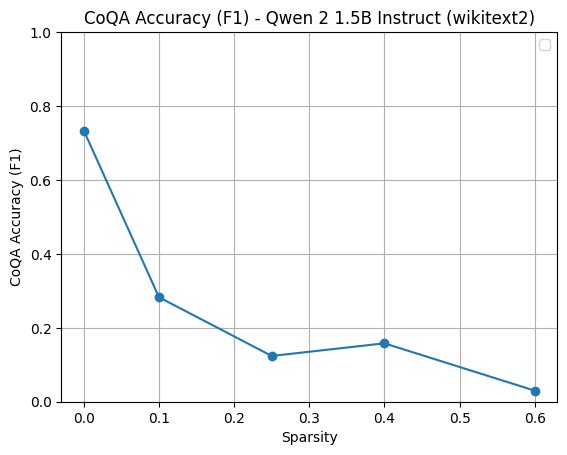

In [ ]:
plotting.plot_sparsity_metric(df, "f1,none", "CoQA Accuracy (F1)", "Qwen 2 1.5B Instruct (wikitext2)", [0, 1])

In [ ]:
df = utils.load_sparsity_eval_results(BASE_EVAL_DIR,
                                      hf_model_name,
                                      "squad",
                                      ["coqa"],
                                      "coqa")

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

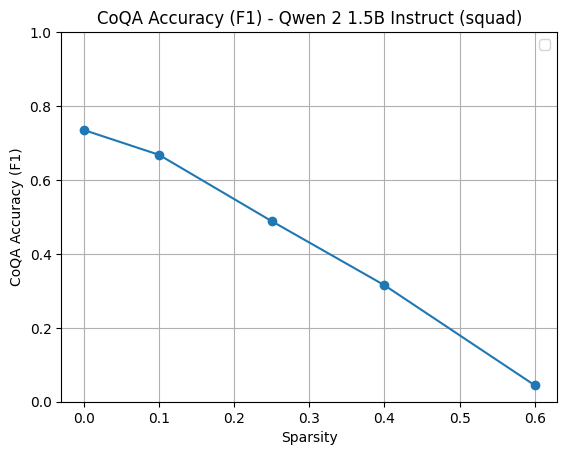

In [ ]:
plotting.plot_sparsity_metric(df, "f1,none", "CoQA Accuracy (F1)", "Qwen 2 1.5B Instruct (squad)", [0, 1])

In [ ]:
df = utils.load_sparsity_eval_results(BASE_EVAL_DIR,
                                      hf_model_name,
                                      "coqa",
                                      ["coqa"],
                                      "coqa")

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

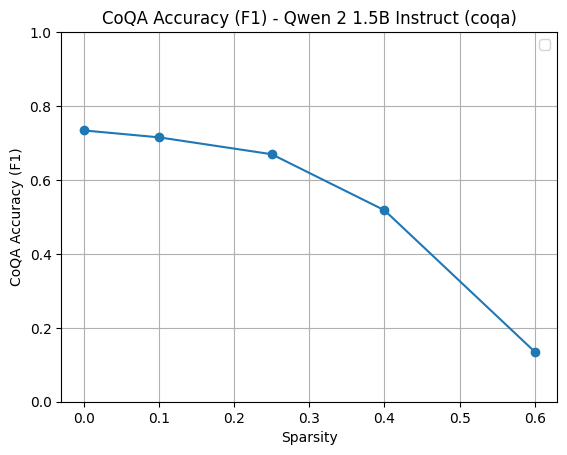

In [ ]:
plotting.plot_sparsity_metric(df, "f1,none", "CoQA Accuracy (F1)", "Qwen 2 1.5B Instruct (coqa)", [0, 1])

In [ ]:
df = utils.load_sparsity_eval_results(BASE_EVAL_DIR,
                                      hf_model_name,
                                      "hotpotqa",
                                      ["coqa"],
                                      "coqa")

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

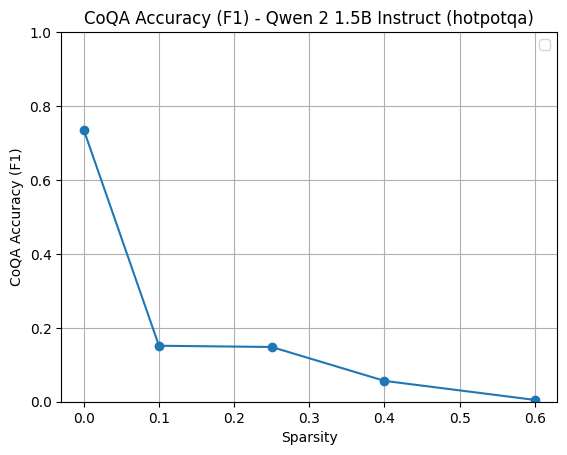

In [ ]:
plotting.plot_sparsity_metric(df, "f1,none", "CoQA Accuracy (F1)", "Qwen 2 1.5B Instruct (hotpotqa)", [0, 1])

In [ ]:
from sliced_rag.hotpot_prediction import generate_hotpot_predictions_sliced

In [ ]:
%cd /content/drive/MyDrive/TUM/Pratikum/code/sliced_rag/
hotpot_dataset_path = "data/hotpot_dev_distractor_v1.json"

/content/drive/.shortcut-targets-by-id/1VRkguTVtRkllTlSID9ugy4MHwCacsE_K/Pratikum/code/sliced_rag


In [ ]:
print(generate_hotpot_predictions_sliced(
    "Qwen/Qwen2-1.5B-Instruct",
    get_model_path(hf_model_name, "squad", 0.0),
    0.0,
    hotpot_dataset_path,
    limit=10
))

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
100%|██████████| 2/2 [00:12<00:00,  6.40s/it]

{'answer': {'5a8b57f25542995d1e6f1371': ': no.', '5a8c7595554299585d9e36b6': ': The woman who portrayed Corliss Archer in the film Kiss and Tell was Shirley Temple Black, who was an American actress, singer, dancer, businesswoman, and diplomat. She was the number one box-office draw as a child actress from 1935 to 1938. Therefore, the', '5a85ea095542994775f606a8': ': The Hork-Bajir Chronicles', '5adbf0a255429947ff17385a': ': Yes. The Laleli Mosque is located in Laleli, Fatih, Istanbul, Turkey, and the Esma Sultan Mansion is also located in the same neighborhood.', '5a8e3ea95542995a26add48d': ': New York City.', '5abd94525542992ac4f382d2': ':YG Entertainment.', '5a85b2d95542997b5ce40028': 'question does not provide information about a person known by the stage name Aladin who helped organizations improve their performance as a consultant. The information provided is about Method Man, Criss Angel, and Lil Ru, but does not mention Aladin. Therefore, the answer to the question cannot be de

In [ ]:
dataset = "hotpotqa"
sparsities = [0.0, 0.1, 0.25, 0.4, 0.6]

OUT_DIR = os.path.join(BASE_EVAL_DIR, f"{hf_model_name.split("/")[-1]}_hotpot_predictions")
os.makedirs(OUT_DIR, exist_ok=True)

for sparsity in sparsities:
    print(f"Sparsity: {sparsity}")

    out_path = os.path.join(OUT_DIR, f"{hf_model_name.split("/")[-1]}_{dataset}_s{sparsity:.2f}_lim1000.json")

    generate_hotpot_predictions_sliced(
        "Qwen/Qwen2-1.5B-Instruct",
        get_model_path(hf_model_name, dataset, sparsity),
        sparsity,
        hotpot_dataset_path,
        out_path=out_path,
        limit=1000
    );

Sparsity: 0.0


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
100%|██████████| 125/125 [06:00<00:00,  2.88s/it]


Predictions saved to /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/eval/Qwen2-1.5B-Instruct_hotpot_predictions/Qwen2-1.5B-Instruct_hotpotqa_s0.00_lim1000.json
Sparsity: 0.1


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
100%|██████████| 125/125 [06:03<00:00,  2.91s/it]


Predictions saved to /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/eval/Qwen2-1.5B-Instruct_hotpot_predictions/Qwen2-1.5B-Instruct_hotpotqa_s0.10_lim1000.json
Sparsity: 0.25


...

Predictions saved to /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/eval/Qwen2-1.5B-Instruct_hotpot_predictions/Qwen2-1.5B-Instruct_hotpotqa_s0.25_lim1000.json
Sparsity: 0.4


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
100%|██████████| 125/125 [05:51<00:00,  2.82s/it]


Predictions saved to /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/eval/Qwen2-1.5B-Instruct_hotpot_predictions/Qwen2-1.5B-Instruct_hotpotqa_s0.40_lim1000.json
Sparsity: 0.6


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
100%|██████████| 125/125 [05:43<00:00,  2.75s/it]

Predictions saved to /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/eval/Qwen2-1.5B-Instruct_hotpot_predictions/Qwen2-1.5B-Instruct_hotpotqa_s0.60_lim1000.json


In [ ]:
dataset = "coqa"
sparsities = [0.0, 0.1, 0.25, 0.4, 0.6]

OUT_DIR = os.path.join(BASE_EVAL_DIR, f"{hf_model_name.split("/")[-1]}_hotpot_predictions")
os.makedirs(OUT_DIR, exist_ok=True)

for sparsity in sparsities:
    print(f"Sparsity: {sparsity}")

    out_path = os.path.join(OUT_DIR, f"{hf_model_name.split("/")[-1]}_{dataset}_s{sparsity:.2f}_lim1000.json")

    generate_hotpot_predictions_sliced(
        "Qwen/Qwen2-1.5B-Instruct",
        get_model_path(hf_model_name, dataset, sparsity),
        sparsity,
        hotpot_dataset_path,
        out_path=out_path,
        limit=1000
    );

Sparsity: 0.0


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
100%|██████████| 125/125 [05:59<00:00,  2.88s/it]


Predictions saved to /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/eval/Qwen2-1.5B-Instruct_hotpot_predictions/Qwen2-1.5B-Instruct_coqa_s0.00_lim1000.json
Sparsity: 0.1


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
100%|██████████| 125/125 [06:03<00:00,  2.90s/it]


Predictions saved to /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/eval/Qwen2-1.5B-Instruct_hotpot_predictions/Qwen2-1.5B-Instruct_coqa_s0.10_lim1000.json
Sparsity: 0.25


...

Predictions saved to /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/eval/Qwen2-1.5B-Instruct_hotpot_predictions/Qwen2-1.5B-Instruct_coqa_s0.25_lim1000.json
Sparsity: 0.4


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
100%|██████████| 125/125 [05:50<00:00,  2.80s/it]


Predictions saved to /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/eval/Qwen2-1.5B-Instruct_hotpot_predictions/Qwen2-1.5B-Instruct_coqa_s0.40_lim1000.json
Sparsity: 0.6


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
100%|██████████| 125/125 [05:44<00:00,  2.76s/it]

Predictions saved to /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/eval/Qwen2-1.5B-Instruct_hotpot_predictions/Qwen2-1.5B-Instruct_coqa_s0.60_lim1000.json


In [ ]:
from google.colab import runtime
runtime.unassign()